In [2]:
import pandas as pd 

df = pd.read_csv("../data/student-mat.csv", sep=";")
#first few rows of data set
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
#colomn data types
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [12]:
#shape of the data set ()
df.shape

(395, 33)

In [5]:
#Checking for missing values
df.isnull().sum()


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [6]:
#Data Cleaning

In [10]:
#Replacing null values with median of the rows
df_median = df.copy()
df_median = df_median.fillna(df_median.median(numeric_only = True))
#df_median = df.fillna(df.median(numeric_only=True))

In [ ]:
#Removing the rolls with null values
df_droped = df.copy()
df_droped = df_droped.dropna()

In [22]:
#Data cleaning , removing duplicates
df_duplicate_rows_count = df.duplicated().sum()
print('Number of duplicate rows :', df_duplicate_rows_count)
df_duplicates_removed = df.copy()
df_duplicates_removed = df.drop_duplicates()
print('Shape of data set with duplicated removed :', df_duplicates_removed.shape)

Number of duplicate rows : 0
Shape of data set with duplicated removed : (395, 33)


### Question 1: What is the average score in Mathematics (G3)?

To determine the average score in Mathematics, we calculate the mean of the **G3** column using pandas.

In [28]:
avg_maths_score = df["G3"].mean()
print('Average score in Maths : ', avg_maths_score)

Average score in Maths :  10.415189873417722


### Answer

The average Mathematics (G3) score of students in the dataset is **10.41**.

In [ ]:
### Question 2: How many students scored above 15 in their final grade (G3)?

We need to check how many students have got marks above 15 for final period maths course **G3** .

In [33]:
count = df[df["G3"] > 15]
print('Above 15 : ', count.shape[0])

Above 15 :  40


In [35]:
count_student = (df["G3"] > 15).sum()
print('Above 15 : ', count_student)

Above 15 :  40


### Answer

The number if students whose marks are above 15 in final maths exam is **40**.

### Question 3: Is there a correlation between study time (study time) and the final grade (G3)?

Here we have to calculate the pearson corelation of study time and G3 .

In [39]:
correlation = df["studytime"].corr(df["G3"])
print(correlation)
if(0 < correlation <= 0.3):
    print('Weak relation.')
elif(0.3 < correlation <= 0.7):
    print('Moderate relation.')
elif(0.7 < correlation <= 1):
    print('Strong relation.')

0.09781968965319636
Weak relation.


### Answer

There is weak relation as the correlation value is **0.0978**.

### Question 4: Which gender has a higher average final grade (G3)?

For this we need to calculate the avarage marks in finals for females and males . And check which has higher.

In [58]:
avg_female = df[df["sex"] == "F"]["G3"].mean()

In [55]:
female = df[df["sex"]== "F"]
female.shape
female_avg = female["G3"].mean()
print('Female avg : ', female_avg)

male = df[df["sex"]== "M"]
female.shape
male_avg = male["G3"].mean()
print('Male avg : ', male_avg)
if(female_avg > male_avg):
    print('Female has average final grade.')
elif(female_avg < male_avg):
    print('Male has average final grade.')

Female avg :  9.966346153846153
Male avg :  10.914438502673796
Male has average final grade.


### Answer
 
**Male** has a higher average final grade.

In [63]:
#Data Analysis using Numpy
#Correlation between study time and final grade

import numpy as np

g3 = df["G3"].to_numpy()
studytime = df["studytime"].to_numpy()

correlation = np.corrcoef(g3, studytime)[0,1]
print(correlation)
if(0 < correlation <= 0.3):
    print('Weak relation.')
elif(0.3 < correlation <= 0.7):
    print('Moderate relation.')
elif(0.7 < correlation <= 1):
    print('Strong relation.')

0.09781968965319636
Weak relation.


In [66]:
# Gender with highest average marks

df_female = df[df["sex"]== "F"]
df_male = df[df["sex"]== "M"]

np_female = df_female["G3"].to_numpy()
np_male = df_male["G3"].to_numpy()

avg_female = np.mean(np_female)
avg_male = np.mean(np_male)

if(female_avg > male_avg):
    print('Female has average final grade.')
elif(female_avg < male_avg):
    print('Male has average final grade.')

Male has average final grade.


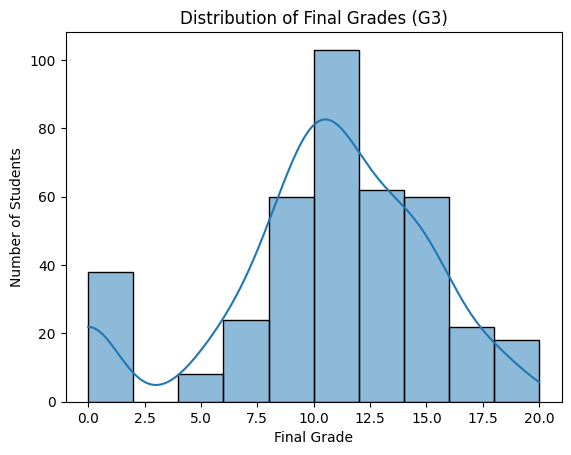

In [12]:
#Data Visualization
## 1. Histogram for final grades 
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["G3"], bins=10, kde=True)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

### Histogram of Final Grades (G3)

A histogram is used to visualize the distribution of final grades among students.

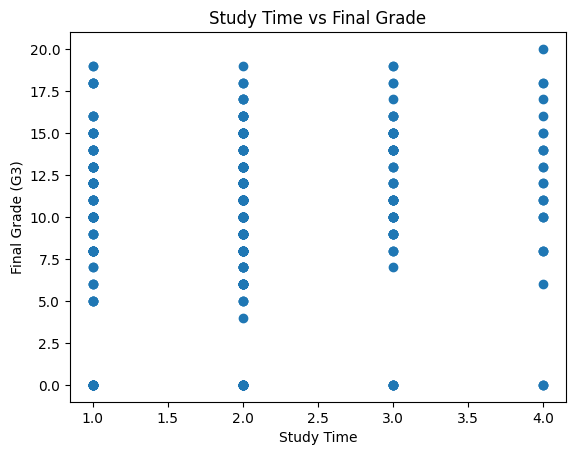

In [14]:
#Create a scatter plot between study time (study time) and final grade (G3).
#Using matplotlib

import matplotlib.pyplot as plt

plt.scatter(df["studytime"], df["G3"])

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")

plt.show()


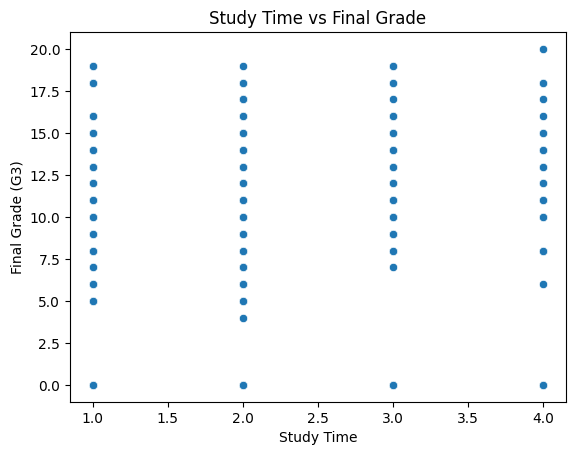

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["studytime"], y=df["G3"])

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")

plt.show()

### Scatter Plot: Study Time vs Final Grade

A scatter plot is used to visualize the relationship between study time and final grade (G3).

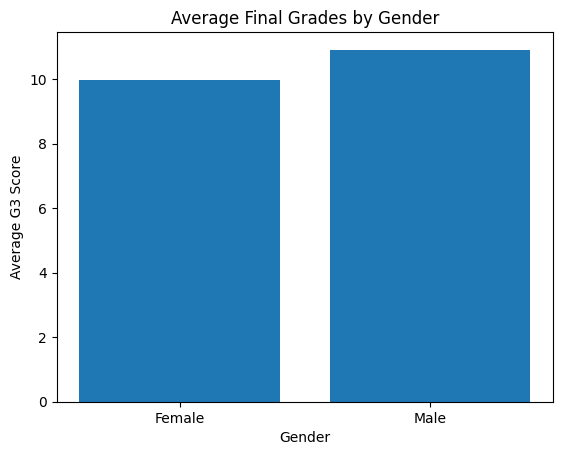

In [21]:
import numpy  as np
female = df[df["sex"] == "F"]
female_np = female["G3"].to_numpy()

male = df[df["sex"] == "M"]
male_np = male["G3"].to_numpy()

female_avg = np.mean(female_np)
male_avg = np.mean(male_np)

import matplotlib.pyplot as plt
genders = ["Female", "Male"]
avg_scores = [female_avg, male_avg]

plt.bar(genders, avg_scores)

plt.title("Average Final Grades by Gender")
plt.xlabel("Gender")
plt.ylabel("Average G3 Score")

plt.show()

### Bar Chart: Average Final Grades by Gender

This bar chart compares the average final mathematics grade (G3) of male and female students.

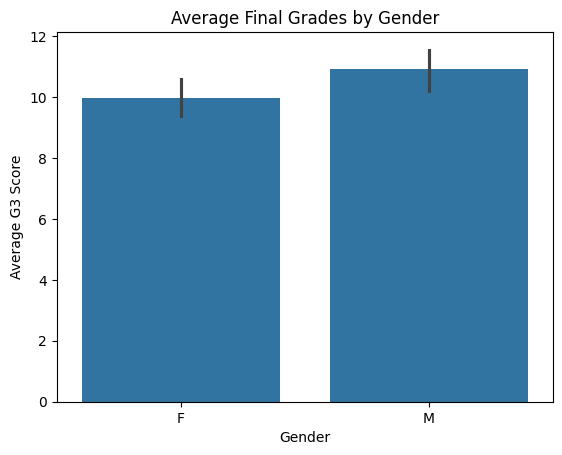

In [22]:
#Using ScatterPlot

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="sex", y="G3", data=df)

plt.title("Average Final Grades by Gender")
plt.xlabel("Gender")
plt.ylabel("Average G3 Score")

plt.show()

### Scatter Plot: Study Time vs Final Grade

A scatter plot is used to visualize the relationship between study time and final grade (G3).